In [1]:
import torch

import xarray as xr
import numpy as np
import pandas as pd

from constants import *
from neural_net_old import get_net

from tqdm.notebook import tqdm
import matplotlib.pyplot as plt

In [2]:
torch.manual_seed(10)

# Settings

In [3]:
device = torch.device("cuda:1")
dtype = torch.bfloat16

In [4]:
batch_size = 32

# Number of ensemble members
n_ensemble = 4

# Integration steps for flow model
n_int = 100

# forecast length
n_forecast_length = 8

lead_time_axis = pd.Timedelta("6h") * np.arange(1, n_forecast_length+1)

# Load data

In [5]:
ds_test = xr.open_zarr("../data/sqg_test.zarr")["q"].compute()
in_mean_np = in_mean.cpu().numpy()
in_std_np  = in_std.cpu().numpy()

ds_test = (ds_test - in_mean_np) / in_std_np

In [6]:
ds_test.time.shape 

(9,)

In [7]:
q_example = ds_test[0]
q_example.shape

(1, 512, 512)

# Estimate score for persistence

In [8]:
initial_conditions = ds_test[:-n_forecast_length]
n_times_total = len(initial_conditions)
print(n_times_total) 

1


In [9]:
persistence_mse = []

pbar = tqdm(np.arange(0, n_times_total, batch_size))
for start_idx in pbar:
    curr_initial = initial_conditions[start_idx:start_idx+batch_size]

    print("Test mean:", ds_test.mean().item())
    print("Test std :", ds_test.std().item())
    print("prediction mean:", curr_initial.mean().item())
    print("prediction std :", curr_initial.std().item())

    # Loop over lead times
    batch_mse = []
    for ld in range(1, n_forecast_length+1):
        # Get prediction
        curr_prediction = curr_initial.values

        # Error estimation
        error = curr_prediction - ds_test[start_idx+ld:start_idx+len(curr_prediction)+ld]
        mse = ((error**2)).mean(["longitude", "latitude"])
        mse = mse.expand_dims(lead_time=[ld*pd.Timedelta("6h")]).assign_coords(time=curr_initial.indexes["time"])
        batch_mse.append(mse)
    batch_mse = xr.concat(batch_mse, dim="lead_time")
    persistence_mse.append(batch_mse)
persistence_mse = xr.concat(persistence_mse, dim="time")

  0%|          | 0/1 [00:00<?, ?it/s]

Test mean: -2.5768403381200155e-16
Test std : 0.9511133583006438
prediction mean: -4.115902497298096e-16
prediction std : 0.9634639671550638


# Deterministic forecast

## Load neural network

In [35]:
n_blocks = 4
n_features = 64
det_model = get_net(
    n_input=1,
    n_output=1, n_blocks=n_blocks, n_features=n_features, mult=2,
    n_embedding=0, wave_length=0.1,
    device=device, dtype=dtype
)
state_dict = torch.load("../data/best_reg_model.ckpt", map_location="cpu")
det_model.load_state_dict(state_dict)
det_model = det_model.eval().to(device=device, dtype=dtype)

TypeError: get_net() got an unexpected keyword argument 'n_blocks'

In [10]:
det_mse = []

pbar = tqdm(np.arange(0, n_times_total, batch_size))
for start_idx in pbar:
    curr_initial = initial_conditions[start_idx:start_idx+batch_size]
    curr_prediction = curr_initial.values

    # Loop over lead times
    batch_mse = []
    for ld in tqdm(range(1, n_forecast_length+1), leave=False):
        # Get prediction
        net_io = torch.from_numpy(curr_prediction)
        net_io = ((net_io-in_mean) / in_std).to(device=device, dtype=dtype)
        with torch.no_grad():
            net_io = det_model(net_io).cpu().float()
        curr_prediction = curr_prediction + (net_io * res_std + res_mean).numpy()

        # Error estimation
        error = curr_prediction - ds_test[start_idx+ld:start_idx+len(curr_prediction)+ld]
        mse = (error**2).mean(["longitude", "latitude"])
        mse = mse.expand_dims(lead_time=[ld*pd.Timedelta("6h")]).assign_coords(time=curr_initial.indexes["time"])
        batch_mse.append(mse)
    batch_mse = xr.concat(batch_mse, dim="lead_time")
    det_mse.append(batch_mse)
det_mse = xr.concat(det_mse, dim="time")

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/8 [00:00<?, ?it/s]

NameError: name 'det_model' is not defined

# Flow matching forecasts

In [10]:
delta_t = 1 / n_int

def sample_with_flow(flow_model, initial_conditions):
    # Collapse the ensemble and batch dimension
    reshaped_conditions = torch.reshape(initial_conditions, (-1, *initial_conditions.shape[2:]))
    # Initialise the flow state with random noise
    dynamics = torch.randn_like(reshaped_conditions)
    
    # Loop through steps
    for t in np.linspace(0, 1, n_int+1)[:-1]:
        # Construct pseudo time
        pseudo_time = torch.full(
            (reshaped_conditions.shape[0], 1), t,
            device=dynamics.device, dtype=dynamics.dtype
        )
        
        # Concatenate flow state and initial conditions
        in_tensor = torch.cat((dynamics, reshaped_conditions), dim=1)

        # Approximate velocity
        velocity = flow_model(in_tensor, pseudo_time)
        # print(f"t={t:.2f} | velocity mean: {velocity.mean().item():.4f} | std: {velocity.std().item():.4f}")


        # Make a Euler step forward
        dynamics = dynamics + delta_t * velocity
    # Get ensemble and batch dimension again
    dynamics = torch.reshape(dynamics, initial_conditions.shape)
    return dynamics

In [11]:
ckpt = torch.load("../data/best_flowcondmodel_test_convnet.ckpt", map_location="cpu")
cfg = ckpt["config"]

flow_model = get_net(
    n_input=cfg["n_input"],
    n_output=cfg["n_output"],
    n_features=cfg["n_features"],
    use_time = cfg["use_time"],
    wave_length=cfg["wave_length"],
    device=device,
    dtype=dtype,
)

# Load weights
flow_model.load_state_dict(ckpt["model_state_dict"])

# Switch to eval + move to device
flow_model = flow_model.eval().to(device=device, dtype=dtype)

# Optional: compile for speed
flow_model = torch.compile(flow_model, mode="reduce-overhead")

In [12]:
print(flow_model.embedding)  # should NOT be None

RandomFourierEmbedding(
  (mlp): Sequential(
    (0): Linear(in_features=256, out_features=256, bias=True)
    (1): SELU()
    (2): Linear(in_features=256, out_features=256, bias=True)
  )
)


In [13]:
print(flow_model.in_layer.weight.shape)  # should be (n_features, 2, 1, 1)

torch.Size([256, 2, 1, 1])


In [14]:
flow_mse_ens = []
flow_mse_mean = []
flow_spread = []

# divide in batches and iterate over them 
# whta is a good number of batches to choose? 
pbar = tqdm(np.arange(0, n_times_total, batch_size))
for start_idx in pbar:
    curr_initial = initial_conditions[start_idx:start_idx+batch_size]
    curr_prediction = curr_initial.values

    # Add ensemble dimension
    curr_prediction = curr_prediction[None].repeat(n_ensemble, axis=0)

    print("curr_prediction mean & std:", curr_prediction.mean().item(), curr_prediction.std().item()) 

    # Loop over lead times
    batch_mse_ens = []
    batch_mse_mean = []
    batch_spread = []
    for ld in tqdm(range(1, n_forecast_length+1), leave=False):
        # Get prediction
        net_io = torch.from_numpy(curr_prediction)
        print("net_ io mean and std:", net_io.mean().item(), net_io.std().item())
        
        net_io = ((net_io-in_mean) / in_std).to(device=device, dtype=dtype)
        with torch.no_grad():
            # for every step in forecast length evaluate the function sample with flow 
            # integrates the stochastic interpolant ODE/SDE 
            net_io = sample_with_flow(flow_model, net_io).cpu().float()
        curr_prediction = curr_prediction + (net_io * res_std + res_mean).numpy()

        # Error estimation for ensemble members
        truth = ds_test[start_idx+ld:start_idx+curr_prediction.shape[1]+ld]
        truth = truth.expand_dims(ensemble=np.arange(n_ensemble), axis=0)

        print("truth mean & std:", truth.mean().item(), truth.std().item()) 
        
        error = curr_prediction - truth
        mse = (error**2).mean(["ensemble", "longitude", "latitude"])
        mse = mse.expand_dims(lead_time=[ld*pd.Timedelta("6h")]).assign_coords(time=curr_initial.indexes["time"])
        batch_mse_ens.append(mse)

        # Error estimation for ensemble mean
        truth = ds_test[start_idx+ld:start_idx+curr_prediction.shape[1]+ld]
        error = curr_prediction.mean(axis=0) - truth
        mse = ((error**2)).mean(["longitude", "latitude"])
        mse = mse.expand_dims(lead_time=[ld*pd.Timedelta("6h")]).assign_coords(time=curr_initial.indexes["time"])
        batch_mse_mean.append(mse)

        # Estimate spread as ensemble variance
        variance = curr_prediction.var(axis=0, ddof=1)
        variance = ds_test[start_idx+ld:start_idx+curr_prediction.shape[1]+ld].copy(data=variance)
        variance = (variance).mean(["longitude", "latitude"])
        variance = variance.expand_dims(lead_time=[ld*pd.Timedelta("6h")]).assign_coords(time=curr_initial.indexes["time"])
        batch_spread.append(variance)

    batch_mse_ens = xr.concat(batch_mse_ens, dim="lead_time")
    flow_mse_ens.append(batch_mse_ens)

    batch_mse_mean = xr.concat(batch_mse_mean, dim="lead_time")
    flow_mse_mean.append(batch_mse_mean)

    batch_spread = xr.concat(batch_spread, dim="lead_time")
    flow_spread.append(batch_spread)

flow_mse_ens = xr.concat(flow_mse_ens, dim="time")
flow_mse_mean = xr.concat(flow_mse_mean, dim="time")
flow_spread = xr.concat(flow_spread, dim="time")

  0%|          | 0/1 [00:00<?, ?it/s]

curr_prediction mean & std: 7.318364664277155e-18 0.9634639671550715


  0%|          | 0/8 [00:00<?, ?it/s]

net_ io mean and std: 6.938893903907228e-18 0.9634644265708198
truth mean & std: 1.018996940931158e-15 0.9563739389484059
net_ io mean and std: -0.019446268535356248 0.9557001101087947
truth mean & std: 1.3858177936294336e-15 0.9538135290061459
net_ io mean and std: -0.038956106184337085 0.9496082183657383
truth mean & std: -1.2649585799130985e-15 0.9586533733349994
net_ io mean and std: -0.05817255438950415 0.9450168332439833
truth mean & std: -9.75485493705415e-17 0.95420540222122
net_ io mean and std: -0.07760934465944931 0.9408230174608819
truth mean & std: -1.1619013517700887e-15 0.9443191154795582
net_ io mean and std: -0.09721757582027307 0.9374363092236065
truth mean & std: -4.2338348945443124e-16 0.9341005312996439
net_ io mean and std: -0.11702071134591437 0.9345552517748296
truth mean & std: 1.8372017571003686e-16 0.9435599550579402
net_ io mean and std: -0.13658638023357042 0.9325033827038879
truth mean & std: -1.4750019985249573e-17 0.9511905091848172


# Plot scores and predictions

# nRMSE

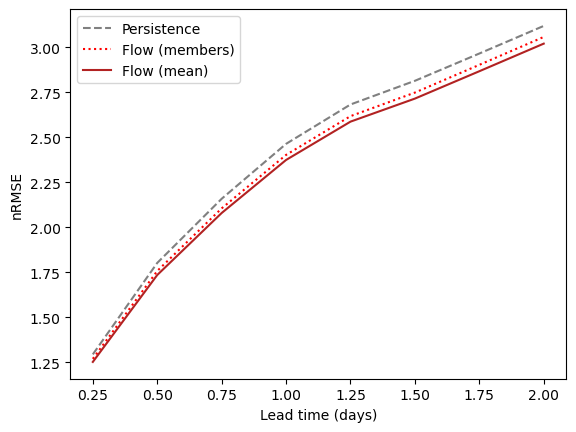

In [15]:
fig, ax = plt.subplots(dpi=100)


ax.plot(
    lead_time_axis/pd.Timedelta("1 day"), np.sqrt((persistence_mse/in_std.squeeze().numpy()**2).mean(["time", "lev"])),
    label="Persistence", c="0.5", ls="--")
#ax.plot(
#    lead_time_axis/pd.Timedelta("1 day"), np.sqrt((det_mse/in_std.squeeze().numpy()**2).mean(["time", "lev"])),
#    label="Deterministic", c="black", ls="-"
#)
ax.plot(
    lead_time_axis/pd.Timedelta("1 day"), np.sqrt((flow_mse_ens/in_std.squeeze().numpy()**2).mean(["time", "lev"])),
    label="Flow (members)", c="red", ls=":"
)
ax.plot(
    lead_time_axis/pd.Timedelta("1 day"), np.sqrt((flow_mse_mean/in_std.squeeze().numpy()**2).mean(["time", "lev"])),
    label="Flow (mean)", c="firebrick"
)

ax.set_ylabel("nRMSE")
ax.set_xlabel("Lead time (days)") 

ax.legend()

# Plot prediction

In [16]:
ds_test.time

<xarray.DataArray 'time' (time: 9)> Size: 72B
array([141., 142., 143., 144., 145., 146., 147., 148., 149.])
Coordinates:
  * time     (time) float64 72B 141.0 142.0 143.0 144.0 ... 147.0 148.0 149.0
Attributes:
    long_name:  model time
    units:      s

In [17]:
start_time = 141
end_time = 149

In [18]:
sliced_truth = ds_test.sel(time=slice(start_time, end_time))
det_prediction = [sliced_truth[0].values[None]]

## Deterministic forecast 
Autoregressive residual forecast; at each step the model predicts the increment $\Delta q$, which is then added to the previous state. 

In [23]:
for _ in tqdm(range(len(sliced_truth)-1)):
    net_io = torch.from_numpy(det_prediction[-1])
    net_io = ((net_io-in_mean) / in_std).to(device=device, dtype=dtype)
    with torch.no_grad():
        net_io = det_model(net_io).cpu().float()
    curr_prediction = det_prediction[-1] + (net_io * res_std + res_mean).numpy()
    det_prediction.append(curr_prediction)

det_prediction = np.concatenate(det_prediction, axis=0)
det_prediction = sliced_truth.copy(data=det_prediction)

  0%|          | 0/8 [00:00<?, ?it/s]

NameError: name 'det_model' is not defined

## Flow model: prediction loop for $\delta x$

  0%|          | 0/8 [00:00<?, ?it/s]

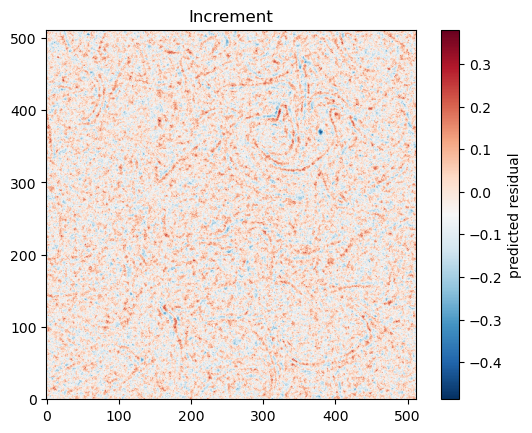

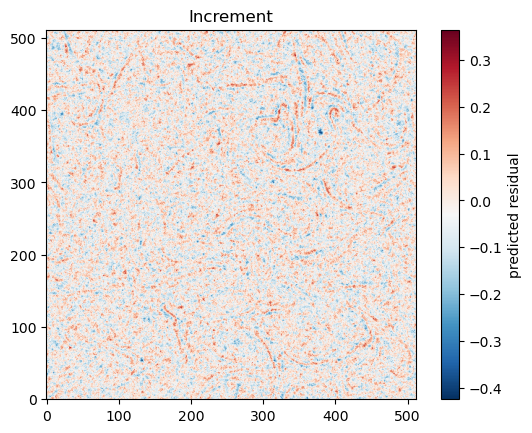

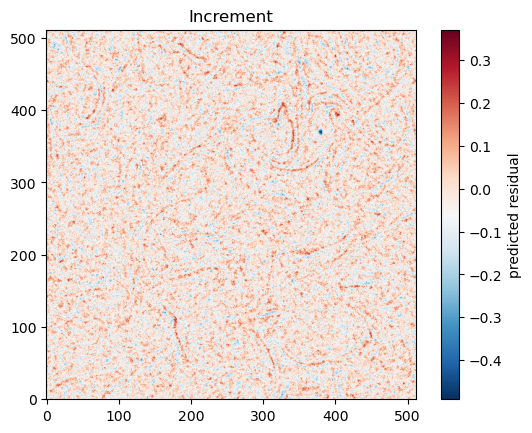

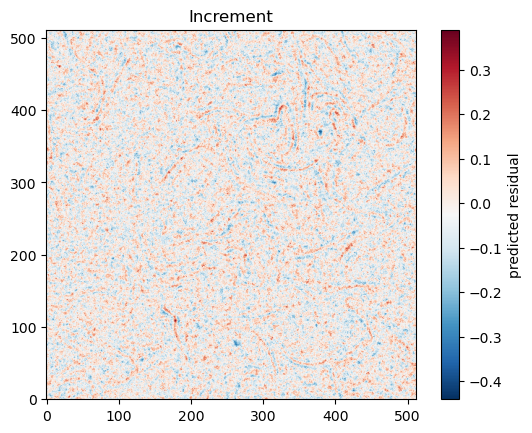

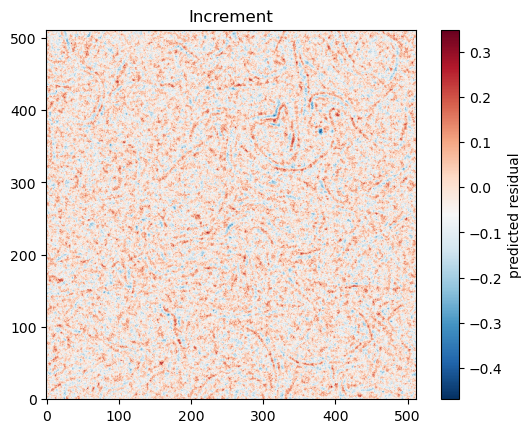

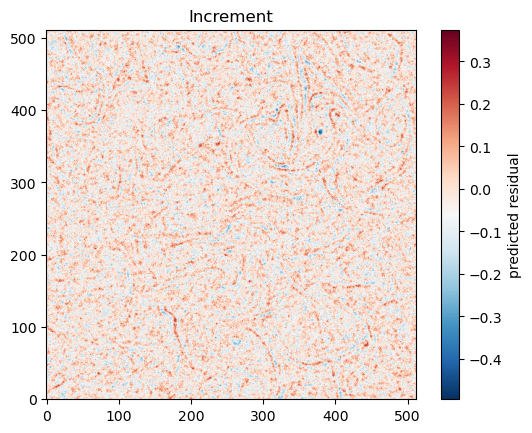

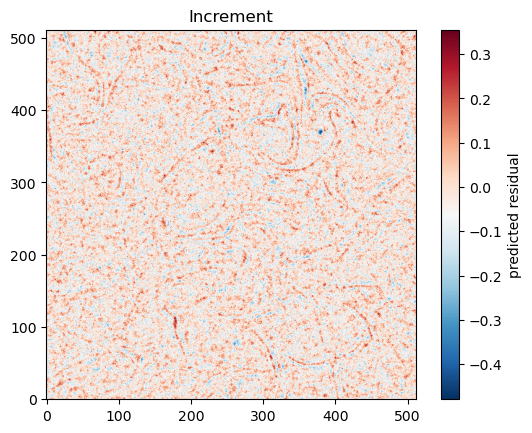

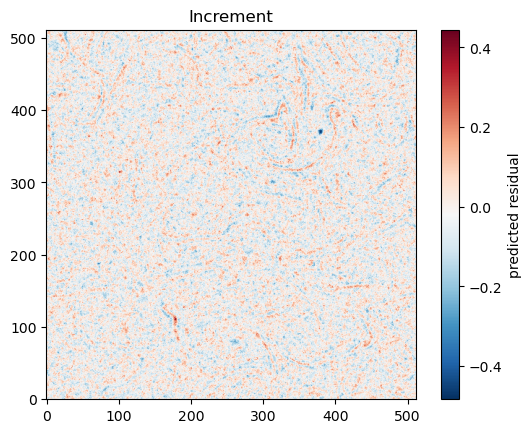

In [19]:
torch.manual_seed(42)
flow_prediction = [sliced_truth[0].values[None, None].repeat(n_ensemble, axis=0)]
all_increments = []  # <-- store them

for _ in tqdm(range(len(sliced_truth)-1)):
    net_io = torch.from_numpy(flow_prediction[-1])
    net_io = ((net_io-in_mean) / in_std).to(device=device, dtype=dtype)
    with torch.no_grad():
        net_io = sample_with_flow(flow_model, net_io).cpu().float()

    # This is the increment alone — plot this
    increment = (net_io * res_std + res_mean).numpy()  # shape: (ensemble, batch, channels, H, W)

    all_increments.append(increment.copy())  # <-- save increment
    
    # Then visualize it directly
    plt.imshow(increment[0, 0, 0], cmap='RdBu_r', origin='lower')
    plt.colorbar(label='predicted residual')
    plt.title('Increment')
    plt.show()
    
    curr_prediction = flow_prediction[-1] + increment

In [20]:
inc = all_increments[0]  # shape: (ensemble, batch, channel, H, W)

# Compare ensemble members
diff = np.abs(inc - inc[0:1]).max()
print("Max difference across ensemble:", diff)

Max difference across ensemble: 0.5076655


## Flow model: prediction loop for $ x_t + \delta x$

In [ ]:
torch.manual_seed(42)
flow_prediction = [sliced_truth[0].values[None, None].repeat(n_ensemble, axis=0)]

for _ in tqdm(range(len(sliced_truth)-1)):
    net_io = torch.from_numpy(flow_prediction[-1])
    net_io = ((net_io-in_mean) / in_std).to(device=device, dtype=dtype)
    with torch.no_grad():
        net_io = sample_with_flow(flow_model, net_io).cpu().float()
    curr_prediction = flow_prediction[-1] + (net_io * res_std + res_mean).numpy()
    flow_prediction.append(curr_prediction)
flow_prediction = np.concatenate(flow_prediction, axis=1)
flow_prediction = sliced_truth.expand_dims(ensemble=np.arange(n_ensemble), axis=0).copy(data=flow_prediction)

### Snapshots of prediction

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Shape: (ensemble, time, channel, x, y)
ensemble_count, time_count, _, nx, ny = flow_prediction.shape

# Choose time indices (example: 10 equally spaced)
time_indices = np.linspace(0, 10, 10, dtype=int)

member_a = 0   # first ensemble member
member_b = 2   # third ensemble member

for t in time_indices:
    
    fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(14, 6))
    
    img_a = flow_prediction[member_a, t, 0]
    img_b = flow_prediction[member_b, t, 0]
    
    # Use same color scale for fair comparison
    vmin = min(img_a.min(), img_b.min())
    vmax = max(img_a.max(), img_b.max())
    
    im0 = axes[0].imshow(img_a, cmap='seismic', origin='lower',
                         vmin=vmin, vmax=vmax)
    axes[0].set_title(f'Member {member_a} — Time {t}')
    axes[0].axis('off')
    
    im1 = axes[1].imshow(img_b, cmap='seismic', origin='lower',
                         vmin=vmin, vmax=vmax)
    axes[1].set_title(f'Member {member_b} — Time {t}')
    axes[1].axis('off')
    
    # Single shared colorbar
    cbar = fig.colorbar(im1, ax=axes, orientation='vertical',
                        fraction=0.046, pad=0.04)
    cbar.set_label('Flow value')
   
    plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Example array shape: (4, 51, 1, 512, 512)
# flow_prediction: [ensemble, time, channel, x, y]
ensemble_count, time_count, _, nx, ny = flow_prediction.shape

# Choose 4 equally spaced time indices
time_indices = np.linspace(1, time_count-1, 4, dtype=int)

fig, axes = plt.subplots(nrows=ensemble_count, ncols=4, figsize=(16, 12))

for i in range(ensemble_count):
    for j, t in enumerate(time_indices):
        ax = axes[i, j]
        # squeeze to remove channel dimension
        img = flow_prediction[i, t, 0, :, :]
        im = ax.imshow(img, cmap='seismic', origin='lower')
        if i == 0:
            ax.set_title(f'Time {t}')
        if j == 0:
            ax.set_ylabel(f'Member {i}')
        ax.axis('off')

# Add a colorbar on the right
cbar = fig.colorbar(im, ax=axes, orientation='vertical', fraction=0.02, pad=0.01)
cbar.set_label('Flow value')
plt.show()

##  Save time evolution gif

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import imageio
import os

# Shape: (ensemble, time, channel, x, y)
ensemble_count, time_count, _, nx, ny = flow_prediction.shape

member = 0  # first ensemble member

# --- Use global color limits for consistency across time ---
vmin = flow_prediction[member, :, 0].min()
vmax = flow_prediction[member, :, 0].max()

frames = []
temp_files = []

for t in range(time_count):
    
    fig, ax = plt.subplots(figsize=(8, 8))
    
    img = flow_prediction[member, t, 0]
    
    im = ax.imshow(
        img,
        cmap='seismic',
        origin='lower',
        vmin=vmin,
        vmax=vmax
    )
    
    ax.set_title(f'Member {member} — Time {t}')
    ax.axis('off')
    
    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label('Flow value')
    
    temp_filename = f"frame_{t}.png"
    fig.savefig(temp_filename, bbox_inches='tight')
    plt.close(fig)
    
    frames.append(imageio.imread(temp_filename))
    temp_files.append(temp_filename)

# --- Save GIF (1 second per frame) ---
gif_name = "ensemble_member0_conditional_forecast.gif"
imageio.mimsave(gif_name, frames, duration=1)

# --- Remove temporary images ---
for f in temp_files:
    os.remove(f)

print(f"GIF saved as: {gif_name}")